In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from astropy.cosmology import Planck18 as cosmo
from scipy.interpolate import interp1d
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
from scipy.ndimage import gaussian_filter1d

In [2]:

# --------------------------------------------------
# HELPERS
# --------------------------------------------------

def read_mrd_file(filename):
    data = np.genfromtxt(filename, comments="#")
    if data.ndim == 1:
        data = data[None, :]

    return {
        "z_mid": data[:, 0],
        "R_source": data[:, 1],
    }


def rebin_xy(z, y, bin_edges, statistic="mean"):
    z = np.asarray(z, dtype=float)
    y = np.asarray(y, dtype=float)

    good = np.isfinite(z) & np.isfinite(y)
    z = z[good]
    y = y[good]

    inds = np.digitize(z, bin_edges) - 1
    nbins = len(bin_edges) - 1

    z_new = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    y_new = np.full(nbins, np.nan)

    for i in range(nbins):
        m = inds == i
        if np.any(m):
            if statistic == "mean":
                y_new[i] = np.mean(y[m])
            elif statistic == "median":
                y_new[i] = np.median(y[m])
            elif statistic == "sum":
                y_new[i] = np.sum(y[m])
            else:
                raise ValueError("statistic must be 'mean', 'median', or 'sum'")

    return z_new, y_new


def prepare_curve(out, bin_edges):
    z = np.asarray(out["z_mid"], dtype=float)
    R = np.asarray(out["R_source"], dtype=float)

    good = np.isfinite(z) & np.isfinite(R) & (R > 0)
    z = z[good]
    R = R[good]

    z, R = rebin_xy(z, R, bin_edges, statistic="mean")

    good = np.isfinite(z) & np.isfinite(R) & (R > 0)
    z = z[good]
    R = R[good]

    # extrapolate to z=0 in log-space using first two valid points
    if len(z) > 1 and z[0] > 0 and R[0] > 0 and R[1] > 0:
        logR0 = np.log10(R[0])
        logR1 = np.log10(R[1])
        slope_log = (logR1 - logR0) / (z[1] - z[0])
        logR_at_0 = logR0 - slope_log * z[0]
        R_at_0 = 10**logR_at_0

        z = np.insert(z, 0, 0.0)
        R = np.insert(R, 0, R_at_0)

    return z, R

def z_to_lookback(z):
    return cosmo.lookback_time(z).value  # Gyr

# build interpolation grid once
z_grid = np.linspace(0, 11, 1000)
t_grid = cosmo.lookback_time(z_grid).value

t_to_z = interp1d(t_grid, z_grid, bounds_error=False, fill_value="extrapolate")



/var/folders/p3/zq_xf6g554d28rrxhsngpp_00000gr/T/ipykernel_79838/4165340947.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  spectral = cm.get_cmap("PiYG")


Loaded keys:
dict_keys([('0.1', 'EL_LAM')])
Loaded keys:
dict_keys([('0.1', 'EL_LAM')])
Saved plot.


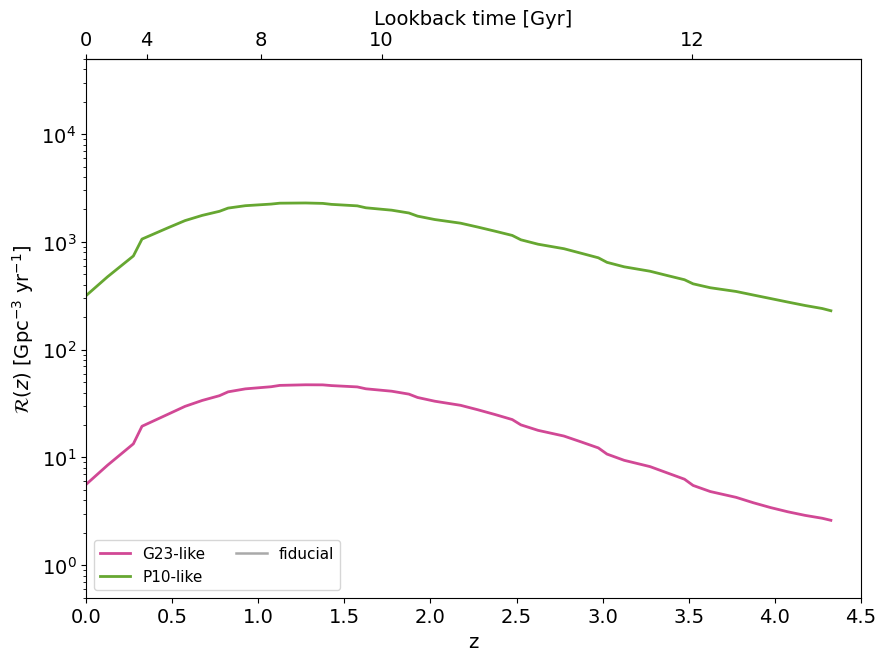

In [ ]:

# --------------------------------------------------
# PARAMETERS
# --------------------------------------------------

alphas = ["0.1"]
redshifts = ["EL_LAM"]

base_dir = "MRD_results"
base_models = ["BIMF_Vaccaro/RD_Rom/TT_G23/Tdisk_10.0/wind_On", 'BIMF_PY/RD_PY/TT_P10/Tdisk_10.0/wind_On']

bin_edges = np.arange(0.0, 4.5, 0.05)

spectral = cm.get_cmap("PiYG") 

palette = {
        "BIMF_Vaccaro/RD_Rom/TT_G23/Tdisk_10.0/wind_On": spectral(0.15),
        "BIMF_PY/RD_PY/TT_P10/Tdisk_10.0/wind_On": spectral(0.85),
}

markers = {
    "0.01": {"EL": "o", "SE": "s"},
    "0.1": {"EL": "^", "SE": "D"},
}

linestyle = {
    "EL_LAM": "-",
    "EL_HAM": (0, (3, 2)),
    "SE_HAM": (2.5, (1, 2)),
}

def smooth_positive_curve(y, sigma=1.0):
    """
    Smooth a positive curve in log-space for plotting.

    Parameters
    ----------
    y : array
        Positive-valued curve.
    sigma : float
        Gaussian smoothing width in index units.
        Try sigma=1.0--2.0.
    """

    y = np.asarray(y, dtype=float)

    good = np.isfinite(y) & (y > 0)
    y_smooth = np.full_like(y, np.nan, dtype=float)

    if good.sum() < 3:
        return y

    logy = np.log10(y[good])
    logy_smooth = gaussian_filter1d(logy, sigma=sigma, mode="nearest")

    y_smooth[good] = 10.0**logy_smooth

    return y_smooth

# --------------------------------------------------
# LOAD FILES + PLOT
# --------------------------------------------------

os.makedirs("plots", exist_ok=True)

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(10, 7))

for base_model in base_models:
    mrd_outputs = {}
    # ----------------------------
    # load all progr files
    # ----------------------------
    for alpha in alphas:
            run_label = f"{base_model}"

            for redshift in redshifts:
                folder = os.path.join(base_dir, f"SG_alpha_{alpha}_{run_label}","Z_0.02", redshift)

                if not os.path.isdir(folder):
                    print(f"Skipping missing folder {folder}")
                    continue

                files = sorted(glob.glob(os.path.join(folder, "MRD_vs_z*.txt")))
                if len(files) == 0:
                    print(f"No MRD file found in {folder}")
                    continue

                if len(files) > 1:
                    print(f"Multiple MRD files found in {folder}, using {files[0]}")

                file = files[0]
                mrd_outputs[(alpha, redshift)] = read_mrd_file(file)

    print("Loaded keys:")
    print(mrd_outputs.keys())

    # ---------------------------------------------------------------------------------------------------------------------------
    # plot, FIGURE 1
    # ---------------------------------------------------------------------------------------------------------------------------

    for alpha in alphas:
        for redshift in redshifts[::-1]:
            pop, abundance = redshift.split("_")

            keys = [(alpha, redshift)]
            missing = [k for k in keys if k not in mrd_outputs]
            if missing:
                print(f"Missing progr entries for alpha={alpha}, redshift={redshift}: {missing}")
                continue

            z_list = []
            R_list = []

            for k in keys:
                z_i, R_i = prepare_curve(mrd_outputs[k], bin_edges)
                z_list.append(z_i)
                R_list.append(R_i)

            z_ref = z_list[0]
            if not all(len(z_ref) == len(z_i) and np.allclose(z_ref, z_i) for z_i in z_list[1:]):
                print(f"Inconsistent z grids for alpha={alpha}, redshift={redshift}")
                continue

            curves = np.vstack(R_list)

            R_low = np.nanmin(curves, axis=0)
            R_high = np.nanmax(curves, axis=0)
            R_avg = np.nanmean(curves, axis=0)

            print(R_avg, z_ref)

            # Smooth only for plotting, not for saved data.
            SMOOTH_SIGMA = 1.5  # try 0.8--2.0
            R_low  = smooth_positive_curve(R_low,  sigma=SMOOTH_SIGMA)
            R_high = smooth_positive_curve(R_high, sigma=SMOOTH_SIGMA)
            R_avg  = smooth_positive_curve(R_avg,  sigma=SMOOTH_SIGMA)

            # style choice:
            # dark line = agnostic color
            # fill = prograde color
            color_main = palette[base_model]
            color_fill = palette[base_model]

            marker = markers[alpha][pop]
            ls = linestyle[redshift]
            mfc = "white" if abundance == "HAM" else color_main

            good_fill = (
                np.isfinite(z_ref) &
                np.isfinite(R_low) &
                np.isfinite(R_high) &
                (R_low > 0) &
                (R_high > 0)
            )

            if np.any(good_fill):
                ax.fill_between(
                    z_ref[good_fill],
                    R_low[good_fill],
                    R_high[good_fill],
                    color=color_fill,
                    alpha=0.2,
                    linewidth=0,
                )

            good_line = (
                np.isfinite(z_ref) &
                np.isfinite(R_avg) &
                (R_avg > 0)
            )

            if np.any(good_line):
                ax.plot(
                    z_ref[good_line],
                    R_avg[good_line],
                    marker=None,#marker,
                    linestyle=ls,
                    color=color_main,
                    markerfacecolor=mfc,
                    markeredgecolor=color_main,
                    markersize=5.,
                    linewidth=2.,
                    markevery=1,
                    label=f"alpha_{alpha}_{redshift}",
                )


ax.set_xlabel("z")
ax.set_ylabel(r"$\mathcal{R}(z)$ [Gpc$^{-3}$ yr$^{-1}$]")
ax.set_yscale("log")
#ax.set_xscale("log")
#ax.set_xlim(5e-1,1.1e1)
ax.set_xlim(0,4.5)
ax.set_ylim(5e-1,5e4)

ax_top = ax.secondary_xaxis('top', functions=(z_to_lookback, t_to_z))
ax_top.set_xlabel("Lookback time [Gyr]")
ax_top.tick_params(axis='both')
ax_top.set_xticks([0,4,8,10,12,13])

# legend
legend_handles = [
    Line2D([0], [0], color=palette["BIMF_Vaccaro/RD_Rom/TT_G23/Tdisk_10.0/wind_On"],  lw=2, label=r"$G23-like$"),

    Line2D([0], [0], color=palette['BIMF_PY/RD_PY/TT_P10/Tdisk_10.0/wind_On'],  lw=2, label=r"$PY-like$"),

    Line2D([0], [0], color="darkgray", lw=1.8, linestyle=linestyle["EL_LAM"], label="fiducial"),


    
    # Patch(facecolor=spm_color, edgecolor=spm_color, alpha=0.5, label="GWTC5"),
    # Patch(facecolor=wpm_color, edgecolor=wpm_color, alpha=0.5, label="GWTC5"),]
]

legend_labels = [
    r"G23-like",
    r"P10-like",
    "fiducial",
]

ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc="lower left",
    frameon=True,
    fontsize=11,
    ncol=2,
)

# plt.savefig(f"plots/MRD_figure.png", dpi=300, bbox_inches="tight")
# print(f"Saved plot.")

plt.show()

